## **1. Imports et configuration**

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path.cwd().parent
PARCELS_PARQUET = PROJECT_ROOT / "data" / "synthetic" / "parcelles_synthetiques.parquet"
MODELS_DIR = PROJECT_ROOT / "data" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Fichier parcelles :", PARCELS_PARQUET.exists())
print("Dossier modèles :", MODELS_DIR)

Fichier parcelles : True
Dossier modèles : c:\Users\engoy\OneDrive - TFM\Desktop\DS Cadastre\projet_foncier_lualaba\data\models


## **2. Charger et préparer les données**

In [27]:
df = pd.read_parquet(PARCELS_PARQUET)
print(f"Dataset : {len(df):,} parcelles, {len(df.columns)} colonnes")
print(f"\nColonnes : {df.columns.tolist()}")
df.head(3)

Dataset : 57,000 parcelles, 12 colonnes

Colonnes : ['id_parcelle', 'province', 'profile', 'latitude', 'longitude', 'superficie_m2', 'statut', 'sous_influence_miniere', 'distance_centre_km', 'valeur_usd', 'type_titre', 'date_enregistrement']


,id_parcelle,province,profile,latitude,longitude,superficie_m2,statut,sous_influence_miniere,distance_centre_km,valeur_usd,type_titre,date_enregistrement
0,HK-000001,Haut-Katanga,mining_urban,-9.963835,28.651323,347.57,formel,False,227.90,4556.51,certificat,2022-02-10
1,HK-000002,Haut-Katanga,mining_urban,-8.439696,27.503674,347.58,litigieux,True,358.09,1070.65,certificat,2021-01-30
2,HK-000003,Haut-Katanga,mining_urban,-11.637689,28.350721,2118.48,formel,False,94.86,55662.36,certificat,2021-04-20


## **3. Feature engineering**

In [28]:
df_feat = df.copy()

# Extraction de l'année d'enregistrement
df_feat["date_enregistrement"] = pd.to_datetime(df_feat["date_enregistrement"])
df_feat["annee_enregistrement"] = df_feat["date_enregistrement"].dt.year

# Log de la superficie (réduit l'effet d'échelle)
df_feat["log_superficie"] = np.log1p(df_feat["superficie_m2"])

# Indicateur d'influence minière en entier (0/1)
df_feat["mining_flag"] = df_feat["sous_influence_miniere"].astype(int)

# Flag zone urbaine (mining_urban = la plus dense)
df_feat["urbain_flag"] = (df_feat["profile"] == "mining_urban").astype(int)

print(f"Features créées :")
print(f"  - annee_enregistrement : {df_feat['annee_enregistrement'].min()} → {df_feat['annee_enregistrement'].max()}")
print(f"  - log_superficie : {df_feat['log_superficie'].describe()}")
print(f"  - mining_flag : {df_feat['mining_flag'].mean()*100:.1f}% des parcelles")
print(f"  - urbain_flag : {df_feat['urbain_flag'].mean()*100:.1f}% des parcelles")

Features créées :
  - annee_enregistrement : 2016 → 2026
  - log_superficie : count    57000.000000
mean         6.670653
std          0.948107
min          3.525183
25%          5.984283
50%          6.591104
75%          7.302941
max         10.954043
Name: log_superficie, dtype: float64
  - mining_flag : 43.8% des parcelles
  - urbain_flag : 35.1% des parcelles


## **4. Définition des features et de la cible**

In [29]:
# Cible
TARGET = "valeur_usd"

# Features numériques
numeric_features = [
    "log_superficie",
    "superficie_m2",
    "distance_centre_km",
    "mining_flag",
    "urbain_flag",
    "annee_enregistrement",
]

# Features catégorielles
categorical_features = [
    "province",
    "statut",
    "type_titre",
    "profile",
]

X = df_feat[numeric_features + categorical_features]
y = df_feat[TARGET]

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"\nTypes des features :")
print(X.dtypes)

X shape : (57000, 10)
y shape : (57000,)

Types des features :
log_superficie          float64
superficie_m2           float64
distance_centre_km      float64
mining_flag               int64
urbain_flag               int64
annee_enregistrement      int32
province                    str
statut                      str
type_titre                  str
profile                     str
dtype: object


## **5.  Split train/test**

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print(f"Train : {len(X_train):,} parcelles")
print(f"Test  : {len(X_test):,} parcelles")
print(f"\nDistribution de la cible (train) :")
print(y_train.describe().round(2))

Train : 45,600 parcelles
Test  : 11,400 parcelles

Distribution de la cible (train) :
count     45600.00
mean       5854.67
std        8694.43
min         500.00
25%        1735.52
50%        3361.18
75%        6671.84
max      381498.72
Name: valeur_usd, dtype: float64


## **6. Pipeline de preprocessing**

In [31]:
# Pipeline de transformation
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

print("Pipeline créé :")
print("  - Numériques : StandardScaler")
print("  - Catégorielles : OneHotEncoder")

Pipeline créé :
  - Numériques : StandardScaler
  - Catégorielles : OneHotEncoder


## **7. Entraîner les 3 modèles**

In [32]:
models = {
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_SEED),
    "Random Forest": RandomForestRegressor(
        n_estimators=100, max_depth=15, n_jobs=-1, random_state=RANDOM_SEED
    ),
    "Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=200, max_depth=10, random_state=RANDOM_SEED
    ),
}

results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Entraînement : {name}")
    print(f"{'='*60}")

    # Pipeline complet
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    # Entraînement
    pipeline.fit(X_train, y_train)

    # Prédictions
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)

    # Métriques
    results[name] = {
        "pipeline": pipeline,
        "r2_train": r2_score(y_train, y_pred_train),
        "r2_test": r2_score(y_test, y_pred_test),
        "rmse_train": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "rmse_test": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "mae_test": mean_absolute_error(y_test, y_pred_test),
    }

    print(f"R² train : {results[name]['r2_train']:.4f}")
    print(f"R² test  : {results[name]['r2_test']:.4f}")
    print(f"RMSE test: {results[name]['rmse_test']:.2f} USD")
    print(f"MAE test : {results[name]['mae_test']:.2f} USD")


Entraînement : Ridge
R² train : 0.5476
R² test  : 0.5708
RMSE test: 5356.05 USD
MAE test : 2852.32 USD

Entraînement : Random Forest
R² train : 0.9908
R² test  : 0.9477
RMSE test: 1870.07 USD
MAE test : 662.70 USD

Entraînement : Gradient Boosting
R² train : 0.9634
R² test  : 0.9431
RMSE test: 1949.64 USD
MAE test : 682.63 USD


## **8. Tableau comparatif des modèles**

In [33]:
comparison = pd.DataFrame({
    name: {
        "R² train": res["r2_train"],
        "R² test": res["r2_test"],
        "RMSE test (USD)": res["rmse_test"],
        "MAE test (USD)": res["mae_test"],
    }
    for name, res in results.items()
}).T.round(4)

print("=== Comparaison des modèles ===")
print(comparison.to_string())

# Identifier le meilleur modèle (R² test le plus élevé)
best_model_name = comparison["R² test"].idxmax()
print(f"\nLe Meilleur modèle est : {best_model_name}")

=== Comparaison des modèles ===
                   R² train  R² test  RMSE test (USD)  MAE test (USD)
Ridge                0.5476   0.5708        5356.0476       2852.3178
Random Forest        0.9908   0.9477        1870.0695        662.6984
Gradient Boosting    0.9634   0.9431        1949.6418        682.6315

Le Meilleur modèle est : Random Forest


## **9. Visualisation : Prédictions vs Réalité**

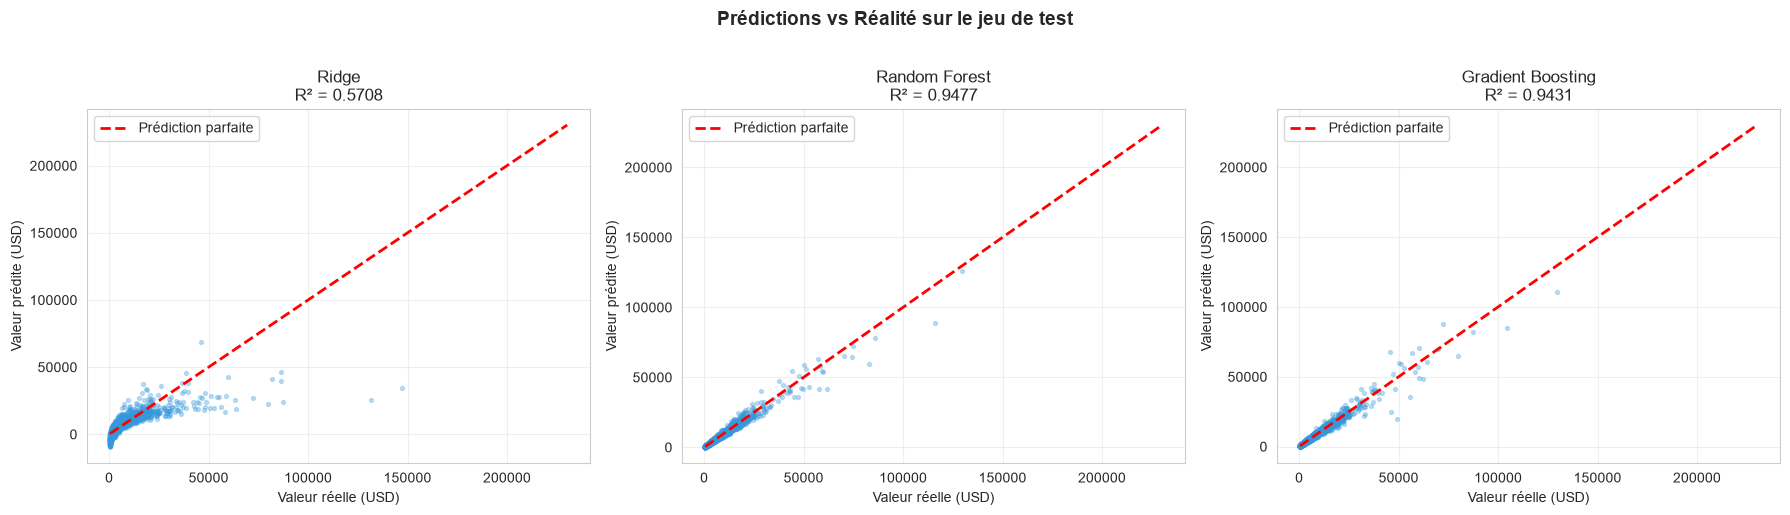

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, res) in enumerate(results.items()):
    pipeline = res["pipeline"]
    y_pred = pipeline.predict(X_test)

    # Échantillon de 3000 points pour la lisibilité
    idx = np.random.choice(len(y_test), size=min(3000, len(y_test)), replace=False)

    axes[i].scatter(y_test.iloc[idx], y_pred[idx], alpha=0.3, s=8, color="#3498db")
    axes[i].plot([y_test.min(), y_test.max()],
                 [y_test.min(), y_test.max()],
                 "r--", linewidth=2, label="Prédiction parfaite")
    axes[i].set_xlabel("Valeur réelle (USD)")
    axes[i].set_ylabel("Valeur prédite (USD)")
    axes[i].set_title(f"{name}\nR² = {res['r2_test']:.4f}")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Prédictions vs Réalité sur le jeu de test", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data" / "synthetic" / "predictions_vs_realite.png", dpi=150, bbox_inches="tight")
plt.show()

## **10. Analyse de l'importance des features (Random Forest)**

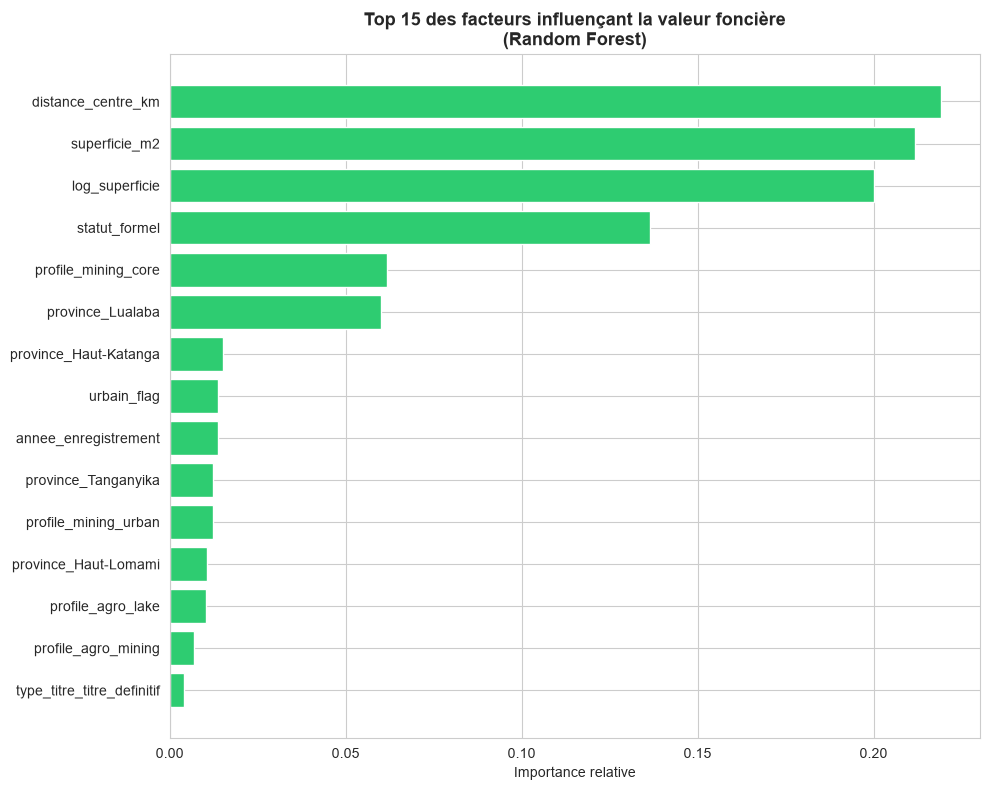


=== Top 10 des facteurs ===
              feature  importance
   distance_centre_km    0.219291
        superficie_m2    0.211739
       log_superficie    0.200029
        statut_formel    0.136428
  profile_mining_core    0.061769
     province_Lualaba    0.060151
province_Haut-Katanga    0.015065
          urbain_flag    0.013743
 annee_enregistrement    0.013584
  province_Tanganyika    0.012232


In [35]:
# Récupérer le pipeline Random Forest
rf_pipeline = results["Random Forest"]["pipeline"]
rf_model = rf_pipeline.named_steps["model"]
preprocessor_fitted = rf_pipeline.named_steps["preprocessor"]

# Récupérer les noms des features après transformation
feature_names_num = numeric_features
feature_names_cat = preprocessor_fitted.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = list(feature_names_num) + list(feature_names_cat)

# Importances
importances = rf_model.feature_importances_

# DataFrame trié
importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances,
}).sort_values("importance", ascending=True)

# Top 15
top_features = importance_df.tail(15)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_features["feature"], top_features["importance"], color="#2ecc71")
ax.set_xlabel("Importance relative")
ax.set_title("Top 15 des facteurs influençant la valeur foncière\n(Random Forest)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data" / "synthetic" / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Top 10 des facteurs ===")
print(importance_df.tail(10).sort_values("importance", ascending=False).to_string(index=False))

## **11. Analyse des résidus du meilleur modèle**

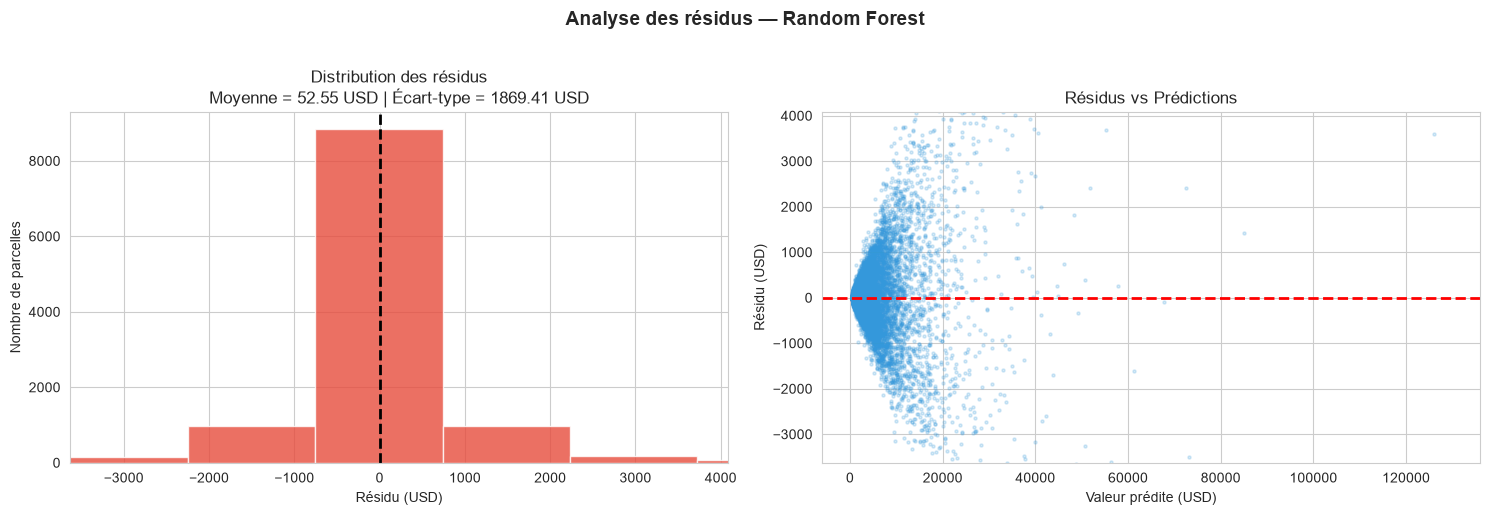


=== Analyse finale : Random Forest ===
R² test  : 0.9477
RMSE test: 1870.07 USD
MAE test : 662.70 USD

Interprétation :
  - Le modèle explique 94.8% de la variance des valeurs
  - Erreur moyenne absolue : 663 USD
  - Valeur médiane des parcelles : 3291 USD
  - Erreur relative moyenne : 20.1% de la médiane


In [36]:
best_pipeline = results[best_model_name]["pipeline"]
y_pred_best = best_pipeline.predict(X_test)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution des résidus
axes[0].hist(residuals, bins=80, color="#e74c3c", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="black", linestyle="--", linewidth=2)
axes[0].set_xlabel("Résidu (USD)")
axes[0].set_ylabel("Nombre de parcelles")
axes[0].set_title(f"Distribution des résidus\nMoyenne = {residuals.mean():.2f} USD | Écart-type = {residuals.std():.2f} USD")
axes[0].set_xlim(residuals.quantile(0.01), residuals.quantile(0.99))

# Résidus vs prédictions
axes[1].scatter(y_pred_best, residuals, alpha=0.2, s=5, color="#3498db")
axes[1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("Valeur prédite (USD)")
axes[1].set_ylabel("Résidu (USD)")
axes[1].set_title("Résidus vs Prédictions")
axes[1].set_ylim(residuals.quantile(0.01), residuals.quantile(0.99))

plt.suptitle(f"Analyse des résidus — {best_model_name}", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data" / "synthetic" / "residus.png", dpi=150, bbox_inches="tight")
plt.show()

# Métriques finales
print(f"\n=== Analyse finale : {best_model_name} ===")
print(f"R² test  : {results[best_model_name]['r2_test']:.4f}")
print(f"RMSE test: {results[best_model_name]['rmse_test']:.2f} USD")
print(f"MAE test : {results[best_model_name]['mae_test']:.2f} USD")
print(f"\nInterprétation :")
print(f"  - Le modèle explique {results[best_model_name]['r2_test']*100:.1f}% de la variance des valeurs")
print(f"  - Erreur moyenne absolue : {results[best_model_name]['mae_test']:.0f} USD")
print(f"  - Valeur médiane des parcelles : {y_test.median():.0f} USD")
print(f"  - Erreur relative moyenne : {(results[best_model_name]['mae_test'] / y_test.median()) * 100:.1f}% de la médiane")

## **12. Sauvegarder le meilleur modèle**  

In [37]:
best_pipeline = results[best_model_name]["pipeline"]

model_path = MODELS_DIR / "modele_valeur_fonciere.joblib"
joblib.dump(best_pipeline, model_path)

print(f" Modèle sauvegardé : {model_path}")
print(f"   Modèle : {best_model_name}")
print(f"   R² test : {results[best_model_name]['r2_test']:.4f}")

# Sauvegarder aussi les métadonnées
metadata = {
    "model_name": best_model_name,
    "r2_test": float(results[best_model_name]["r2_test"]),
    "rmse_test": float(results[best_model_name]["rmse_test"]),
    "mae_test": float(results[best_model_name]["mae_test"]),
    "training_date": datetime.now().isoformat(),
    "n_train": len(X_train),
    "n_test": len(X_test),
    "features_numeric": numeric_features,
    "features_categorical": categorical_features,
}

import json
metadata_path = MODELS_DIR / "modele_valeur_fonciere_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f" Métadonnées sauvegardées : {metadata_path}")

 Modèle sauvegardé : c:\Users\engoy\OneDrive - TFM\Desktop\DS Cadastre\projet_foncier_lualaba\data\models\modele_valeur_fonciere.joblib
   Modèle : Random Forest
   R² test : 0.9477
 Métadonnées sauvegardées : c:\Users\engoy\OneDrive - TFM\Desktop\DS Cadastre\projet_foncier_lualaba\data\models\modele_valeur_fonciere_metadata.json
